# RF-DETR — Probe BODY & TAIL Detection Training

**Folder layout (everything self-contained here):**
```
REDetr_Probe_Detection_Training/
  train_rfdetr.ipynb        ← this file
  dataset/
    train/  valid/  test/
      *.jpg  +  _annotations.coco.json
  runs/
    checkpoint_best_total.pth
    checkpoint_*.pth
```

**Source data** (read-only):
```
../Annotated_Videos/<video>/cropped_video_clips_frames/<clip>/*.jpg
../Annotated_Videos/<video>/segmentations_masks/<clip>.npz
../Annotated_Videos/<video>/cropped_clips_metadata/<clip>.json
```

**Classes:** `1 = BODY` (green)  |  `2 = TAIL` (red)

## 1. Install Dependencies

In [1]:
%pip install rfdetr supervision opencv-python-headless tqdm matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. GPU Check

In [2]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError('No CUDA GPU detected. Training on CPU would take days — stop here and fix the environment.')

gpu_name  = torch.cuda.get_device_name(0)
vram_gb   = torch.cuda.get_device_properties(0).total_memory / 1e9
DEVICE    = 'cuda'

print(f'GPU   : {gpu_name}')
print(f'VRAM  : {vram_gb:.1f} GB')
print(f'CUDA  : {torch.version.cuda}')
print(f'PyTorch: {torch.__version__}')
print('Ready to train.')

GPU   : NVIDIA GeForce RTX 5090
VRAM  : 34.2 GB
CUDA  : 12.8
PyTorch: 2.11.0+cu128
Ready to train.


## 3. Configuration

In [15]:
import os
from rfdetr import RFDETRSmall, RFDETRLarge

HERE = os.path.abspath('')
ROOT = os.path.dirname(HERE)

ANNOTATED_VIDEOS_DIR = os.path.join(ROOT, 'Annotated_Videos')
DATASET_DIR          = os.path.join(HERE, 'dataset')
RUNS_DIR             = os.path.join(HERE, 'runs')

VAL_RATIO   = 0.15
TEST_RATIO  = 0.10
RANDOM_SEED = 42

FRAME_STRIDE = 5

CLEAN_MASKS   = True
KERNEL_SIZE   = 5
MORPH_ITERS   = 1
MIN_MASK_AREA = 50

# RFDETRSmall → faster (~370 MB)   RFDETRLarge → more accurate (~800 MB)
MODEL_CLASS = RFDETRSmall
EPOCHS      = 30
BATCH_SIZE  = 16
LR          = 1e-4
IMG_SIZE    = 560

CATEGORIES   = [
    {'id': 1, 'name': 'BODY', 'supercategory': 'probe'},
    {'id': 2, 'name': 'TAIL', 'supercategory': 'probe'},
]
CLASS_COLORS = {1: '#00ff00', 2: '#ff0000'}
CLASS_NAMES  = {1: 'BODY',   2: 'TAIL'}

for d in (DATASET_DIR, RUNS_DIR):
    os.makedirs(d, exist_ok=True)

print(f'Model   : {MODEL_CLASS.__name__}')
print(f'Dataset : {DATASET_DIR}')
print(f'Runs    : {RUNS_DIR}')

Model   : RFDETRSmall
Dataset : c:\Users\Krish\Desktop\scanner-annotation\REDetr_Probe_Detection_Training\dataset
Runs    : c:\Users\Krish\Desktop\scanner-annotation\REDetr_Probe_Detection_Training\runs


## 4. Clean Source Selection

Only **verified, fully post-processed** clips are included.  
Partially reviewed or unannotated halves are excluded.

| Video | Clip | Frames | Status |
|---|---|---|---|
| `QMLwebcam_recording_2026-03-17T02-07-33-864Z` | `full_scanner_0_to_11_clean` | 7,845 | ✅ fully done |
| `QMLwebcam_recording_2026-05-12T09-32-46-130Z` | `full_scanner_0_to_15_clean` | 11,575 | ✅ fully done |
| `QMLwebcam_recording__2026-02-26T02-35-32-034Z` | `full_scanner_0_to_12` | 11,763 | ✅ fully done |
| `QMLwebcam_recording__2026-02-26T02-59-15-295Z` | `full_scanner_0_to_1` | 1,419 | ✅ fully done |
| `QMLwebcam_recording__2026-03-17T01-22-52-304Z` | `full_scanner_0_to_17_clean` | 15,892 | ✅ fully done |
| `QMLwebcam_recording_2026-04-30T08-50-07-689Z` | `full_scanner_0_to_19_clean` | 15,184 | ✅ 1st half done |
| `QMLwebcam_recording_2026-05-12T09-49-11-071Z` | `full_scanner_19_to_37_clean` | 10,273 | ✅ 2nd half done |

In [4]:
# Each entry: video_name → list of clip stems to include (no .npz extension)
CLEAN_CLIPS = {
    'QMLwebcam_recording_2026-03-17T02-07-33-864Z':  ['full_scanner_0_to_11_clean'],
    'QMLwebcam_recording_2026-05-12T09-32-46-130Z':  ['full_scanner_0_to_15_clean'],
    'QMLwebcam_recording__2026-02-26T02-35-32-034Z': ['full_scanner_0_to_12'],
    'QMLwebcam_recording__2026-02-26T02-59-15-295Z': ['full_scanner_0_to_1'],
    'QMLwebcam_recording__2026-03-17T01-22-52-304Z': ['full_scanner_0_to_17_clean'],
    # Split videos — verified half only:
    'QMLwebcam_recording_2026-04-30T08-50-07-689Z':  ['full_scanner_0_to_19_clean'],
    'QMLwebcam_recording_2026-05-12T09-49-11-071Z':  ['full_scanner_19_to_37_clean'],
}

print(f'{len(CLEAN_CLIPS)} videos  |  {sum(len(v) for v in CLEAN_CLIPS.values())} clips')

7 videos  |  7 clips


## 5. Build Dataset

Reads each clean clip at every `FRAME_STRIDE`-th frame, crops images and masks to the scan region, extracts bounding boxes, and writes JPGs + COCO JSON into `dataset/train|valid|test/`.

**Run this section only once** — skip to Section 6 if the dataset folder already exists and is populated.

In [5]:
import json, random
import cv2
import numpy as np
from collections import defaultdict
from tqdm.auto import tqdm


def clean_mask(mask, ksize=5, iters=1):
    m  = mask.astype(np.uint8)
    ko = np.ones((ksize, ksize), np.uint8)
    kc = np.ones((max(1, ksize // 2), max(1, ksize // 2)), np.uint8)
    m  = cv2.morphologyEx(m, cv2.MORPH_OPEN,  ko, iterations=iters)
    m  = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kc, iterations=iters)
    return m


def mask_to_bbox(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    return [int(xs.min()), int(ys.min()),
            int(xs.max()) - int(xs.min()),
            int(ys.max()) - int(ys.min())]


# ── Video-level split ─────────────────────────────────────────────────────────
all_videos = sorted(CLEAN_CLIPS.keys())
random.seed(RANDOM_SEED)
random.shuffle(all_videos)

n_test = max(1, round(len(all_videos) * TEST_RATIO))
n_val  = max(1, round(len(all_videos) * VAL_RATIO))
test_set  = set(all_videos[:n_test])
val_set   = set(all_videos[n_test:n_test + n_val])
train_set = set(all_videos[n_test + n_val:])

def which_split(v):
    if v in test_set: return 'test'
    if v in val_set:  return 'valid'
    return 'train'

print('Split assignment:')
for v in all_videos:
    print(f'  {which_split(v):6s}  {v}')

Split assignment:
  test    QMLwebcam_recording_2026-04-30T08-50-07-689Z
  valid   QMLwebcam_recording_2026-05-12T09-49-11-071Z
  train   QMLwebcam_recording__2026-02-26T02-35-32-034Z
  train   QMLwebcam_recording_2026-05-12T09-32-46-130Z
  train   QMLwebcam_recording__2026-03-17T01-22-52-304Z
  train   QMLwebcam_recording_2026-03-17T02-07-33-864Z
  train   QMLwebcam_recording__2026-02-26T02-59-15-295Z


In [6]:
for split in ('train', 'valid', 'test'):
    os.makedirs(os.path.join(DATASET_DIR, split), exist_ok=True)

split_imgs = defaultdict(list)
split_anns = defaultdict(list)
img_ids    = defaultdict(lambda: 1)
ann_ids    = defaultdict(lambda: 1)
skipped = total = sampled = 0

for video_name, clip_list in tqdm(CLEAN_CLIPS.items(), desc='Videos'):
    video_dir   = os.path.join(ANNOTATED_VIDEOS_DIR, video_name)
    frames_base = os.path.join(video_dir, 'cropped_video_clips_frames')
    masks_base  = os.path.join(video_dir, 'segmentations_masks')
    meta_base   = os.path.join(video_dir, 'cropped_clips_metadata')
    split       = which_split(video_name)

    for clip_stem in clip_list:
        frames_dir = os.path.join(frames_base, clip_stem)
        seg_path   = os.path.join(masks_base,  clip_stem + '.npz')
        meta_path  = os.path.join(meta_base,   clip_stem + '.json')

        if not os.path.isdir(frames_dir):
            print(f'  [WARN] frames dir missing: {clip_stem}'); continue
        if not os.path.exists(seg_path):
            print(f'  [WARN] mask missing: {clip_stem}'); continue

        crop = None
        if os.path.exists(meta_path):
            with open(meta_path) as f:
                crop = json.load(f).get('crop_region')

        seg        = np.load(seg_path)
        frame_list = sorted(os.listdir(frames_dir))

        for fidx, fname in enumerate(tqdm(frame_list, desc=clip_stem, leave=False)):
            total += 1
            # ── stride: only process every Nth frame ──────────────────────────
            if fidx % FRAME_STRIDE != 0:
                continue
            sampled += 1

            key = str(fidx)
            if key not in seg:
                skipped += 1; continue

            img = cv2.imread(os.path.join(frames_dir, fname))
            if img is None:
                skipped += 1; continue

            if crop:
                x0, y0, x1, y1 = crop
                img = img[y0:y1, x0:x1]
            h, w = img.shape[:2]

            frame_masks = seg[key]   # (num_classes, H, W) bool
            frame_anns  = []

            for ch, raw in enumerate(frame_masks):
                cat_id = ch + 1
                if crop:
                    raw = raw[y0:y1, x0:x1]
                if CLEAN_MASKS:
                    raw = clean_mask(raw, KERNEL_SIZE, MORPH_ITERS)
                if raw.sum() < MIN_MASK_AREA:
                    continue
                bbox = mask_to_bbox(raw)
                if bbox is None or bbox[2] < 2 or bbox[3] < 2:
                    continue
                bx, by, bw, bh = bbox
                frame_anns.append({
                    'id': ann_ids[split], 'image_id': img_ids[split],
                    'category_id': cat_id,
                    'bbox': [float(bx), float(by), float(bw), float(bh)],
                    'area': float(bw * bh), 'iscrowd': 0, 'segmentation': [],
                })
                ann_ids[split] += 1

            if not frame_anns:
                skipped += 1; continue

            out_fname = f'{video_name}__{clip_stem}__{fidx:05d}.jpg'
            cv2.imwrite(os.path.join(DATASET_DIR, split, out_fname), img)

            split_imgs[split].append({
                'id': img_ids[split], 'file_name': out_fname,
                'width': w, 'height': h,
            })
            split_anns[split].extend(frame_anns)
            img_ids[split] += 1

        seg.close()

# ── Write COCO JSON ───────────────────────────────────────────────────────────
COCO_INFO = {'year': 2026, 'version': '1.0',
             'description': 'Probe BODY & TAIL Detection — clean subset'}
for split in ('train', 'valid', 'test'):
    coco = {'info': COCO_INFO, 'licenses': [], 'categories': CATEGORIES,
            'images': split_imgs[split], 'annotations': split_anns[split]}
    with open(os.path.join(DATASET_DIR, split, '_annotations.coco.json'), 'w') as f:
        json.dump(coco, f)

print(f'\n{"split":8s}  {"images":>8s}  {"BODY":>8s}  {"TAIL":>8s}  {"total anns":>10s}')
print('-' * 50)
for s in ('train', 'valid', 'test'):
    b = sum(1 for a in split_anns[s] if a['category_id'] == 1)
    t = sum(1 for a in split_anns[s] if a['category_id'] == 2)
    print(f'{s:8s}  {len(split_imgs[s]):8d}  {b:8d}  {t:8d}  {b+t:10d}')
print(f'\nSource frames: {total}  |  Sampled (stride={FRAME_STRIDE}): {sampled}  |  Skipped (no ann): {skipped}')

Videos:   0%|          | 0/7 [00:00<?, ?it/s]

full_scanner_0_to_11_clean:   0%|          | 0/7845 [00:00<?, ?it/s]

full_scanner_0_to_15_clean:   0%|          | 0/11575 [00:00<?, ?it/s]

full_scanner_0_to_12:   0%|          | 0/11763 [00:00<?, ?it/s]

full_scanner_0_to_1:   0%|          | 0/1419 [00:00<?, ?it/s]

full_scanner_0_to_17_clean:   0%|          | 0/15892 [00:00<?, ?it/s]

full_scanner_0_to_19_clean:   0%|          | 0/15184 [00:00<?, ?it/s]

full_scanner_19_to_37_clean:   0%|          | 0/10273 [00:00<?, ?it/s]


split       images      BODY      TAIL  total anns
--------------------------------------------------
train         6295      5268      5346       10614
valid          848       675       712        1387
test          1957       383      1910        2293

Source frames: 73951  |  Sampled (stride=5): 14792  |  Skipped (no ann): 5692


## 6. Dataset Visualisations

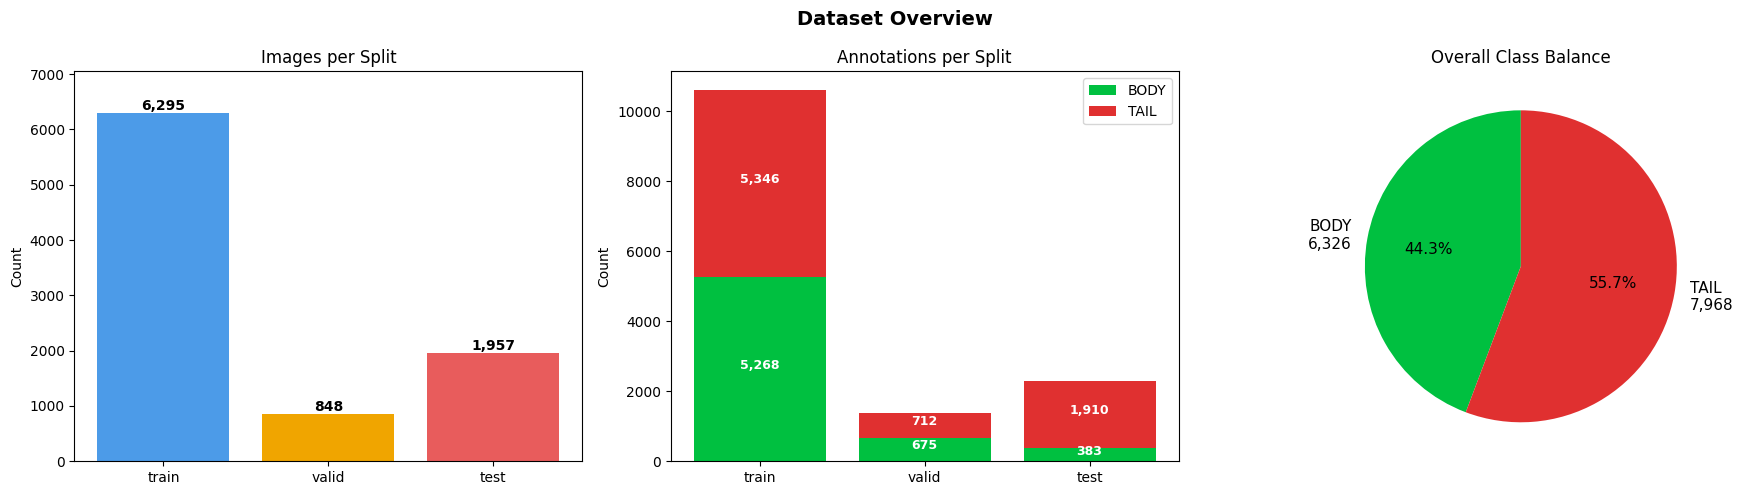

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def load_coco(split):
    with open(os.path.join(DATASET_DIR, split, '_annotations.coco.json')) as f:
        return json.load(f)

stats = {}
for split in ('train', 'valid', 'test'):
    coco = load_coco(split)
    stats[split] = {
        'images': len(coco['images']),
        'body':   sum(1 for a in coco['annotations'] if a['category_id'] == 1),
        'tail':   sum(1 for a in coco['annotations'] if a['category_id'] == 2),
        'anns':   coco['annotations'],
    }

splits = ['train', 'valid', 'test']
images = [stats[s]['images'] for s in splits]
body   = [stats[s]['body']   for s in splits]
tail   = [stats[s]['tail']   for s in splits]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

# Image counts
bars = axes[0].bar(splits, images, color=['#4c9be8', '#f0a500', '#e85c5c'])
for bar, v in zip(bars, images):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + max(images)*0.01,
                 f'{v:,}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Images per Split'); axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(images) * 1.12)

# Stacked BODY / TAIL
x = np.arange(len(splits))
axes[1].bar(x, body, label='BODY', color='#00c040')
axes[1].bar(x, tail, bottom=body, label='TAIL', color='#e03030')
axes[1].set_xticks(x); axes[1].set_xticklabels(splits)
axes[1].set_title('Annotations per Split'); axes[1].set_ylabel('Count')
axes[1].legend()
for i in range(len(splits)):
    if body[i]: axes[1].text(i, body[i]/2, f'{body[i]:,}', ha='center', color='white', fontweight='bold', fontsize=9)
    if tail[i]: axes[1].text(i, body[i]+tail[i]/2, f'{tail[i]:,}', ha='center', color='white', fontweight='bold', fontsize=9)

# Overall class pie
tb, tt = sum(body), sum(tail)
axes[2].pie([tb, tt], labels=[f'BODY\n{tb:,}', f'TAIL\n{tt:,}'],
            colors=['#00c040', '#e03030'], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[2].set_title('Overall Class Balance')

plt.tight_layout()
plt.savefig(os.path.join(HERE, 'dataset_overview.png'), dpi=120, bbox_inches='tight')
plt.show()

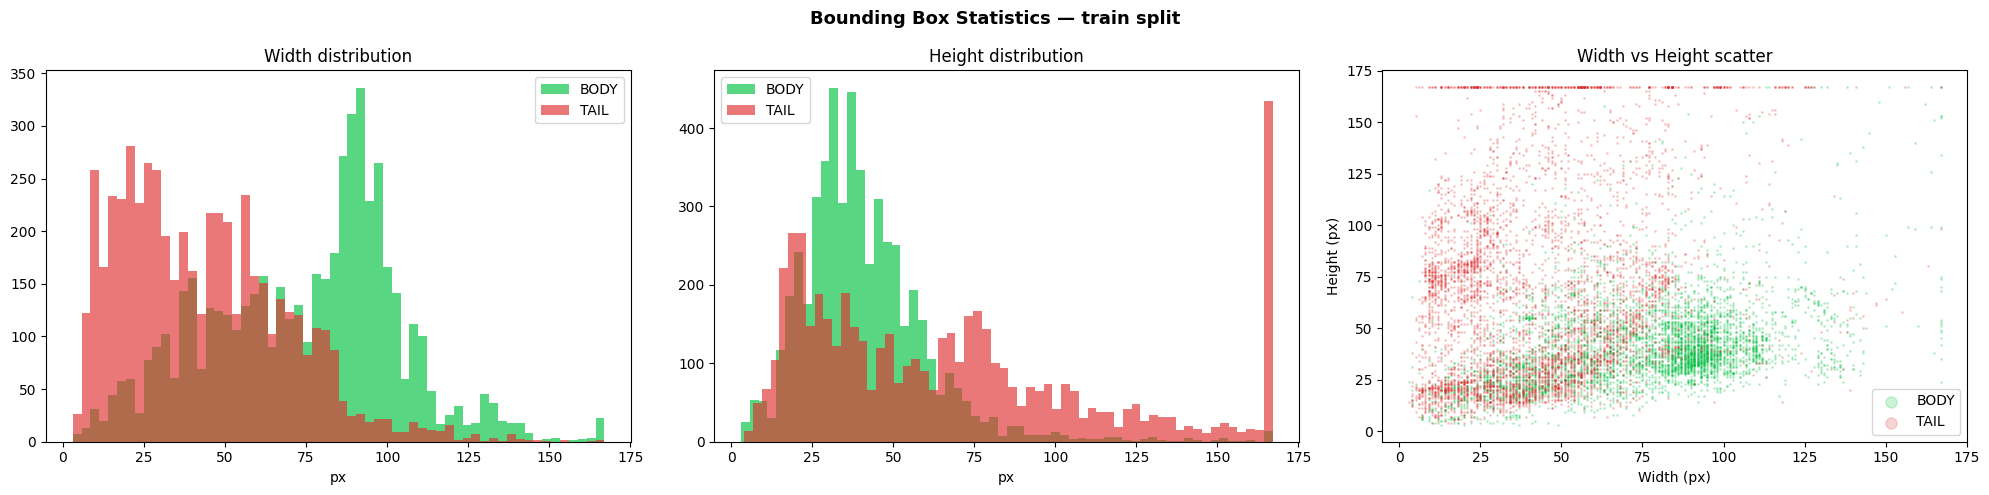

In [8]:
# ── BBox size distributions ───────────────────────────────────────────────────
train_anns = stats['train']['anns']
body_w = [a['bbox'][2] for a in train_anns if a['category_id'] == 1]
body_h = [a['bbox'][3] for a in train_anns if a['category_id'] == 1]
tail_w = [a['bbox'][2] for a in train_anns if a['category_id'] == 2]
tail_h = [a['bbox'][3] for a in train_anns if a['category_id'] == 2]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Bounding Box Statistics — train split', fontsize=13, fontweight='bold')
kw = dict(bins=60, alpha=0.65, edgecolor='none')

axes[0].hist(body_w, color='#00c040', label='BODY', **kw)
axes[0].hist(tail_w, color='#e03030', label='TAIL', **kw)
axes[0].set_title('Width distribution'); axes[0].set_xlabel('px'); axes[0].legend()

axes[1].hist(body_h, color='#00c040', label='BODY', **kw)
axes[1].hist(tail_h, color='#e03030', label='TAIL', **kw)
axes[1].set_title('Height distribution'); axes[1].set_xlabel('px'); axes[1].legend()

axes[2].scatter(body_w, body_h, s=1, alpha=0.2, color='#00c040', label='BODY')
axes[2].scatter(tail_w, tail_h, s=1, alpha=0.2, color='#e03030', label='TAIL')
axes[2].set_title('Width vs Height scatter'); axes[2].set_xlabel('Width (px)'); axes[2].set_ylabel('Height (px)')
axes[2].legend(markerscale=8)

plt.tight_layout()
plt.savefig(os.path.join(HERE, 'bbox_stats.png'), dpi=120, bbox_inches='tight')
plt.show()

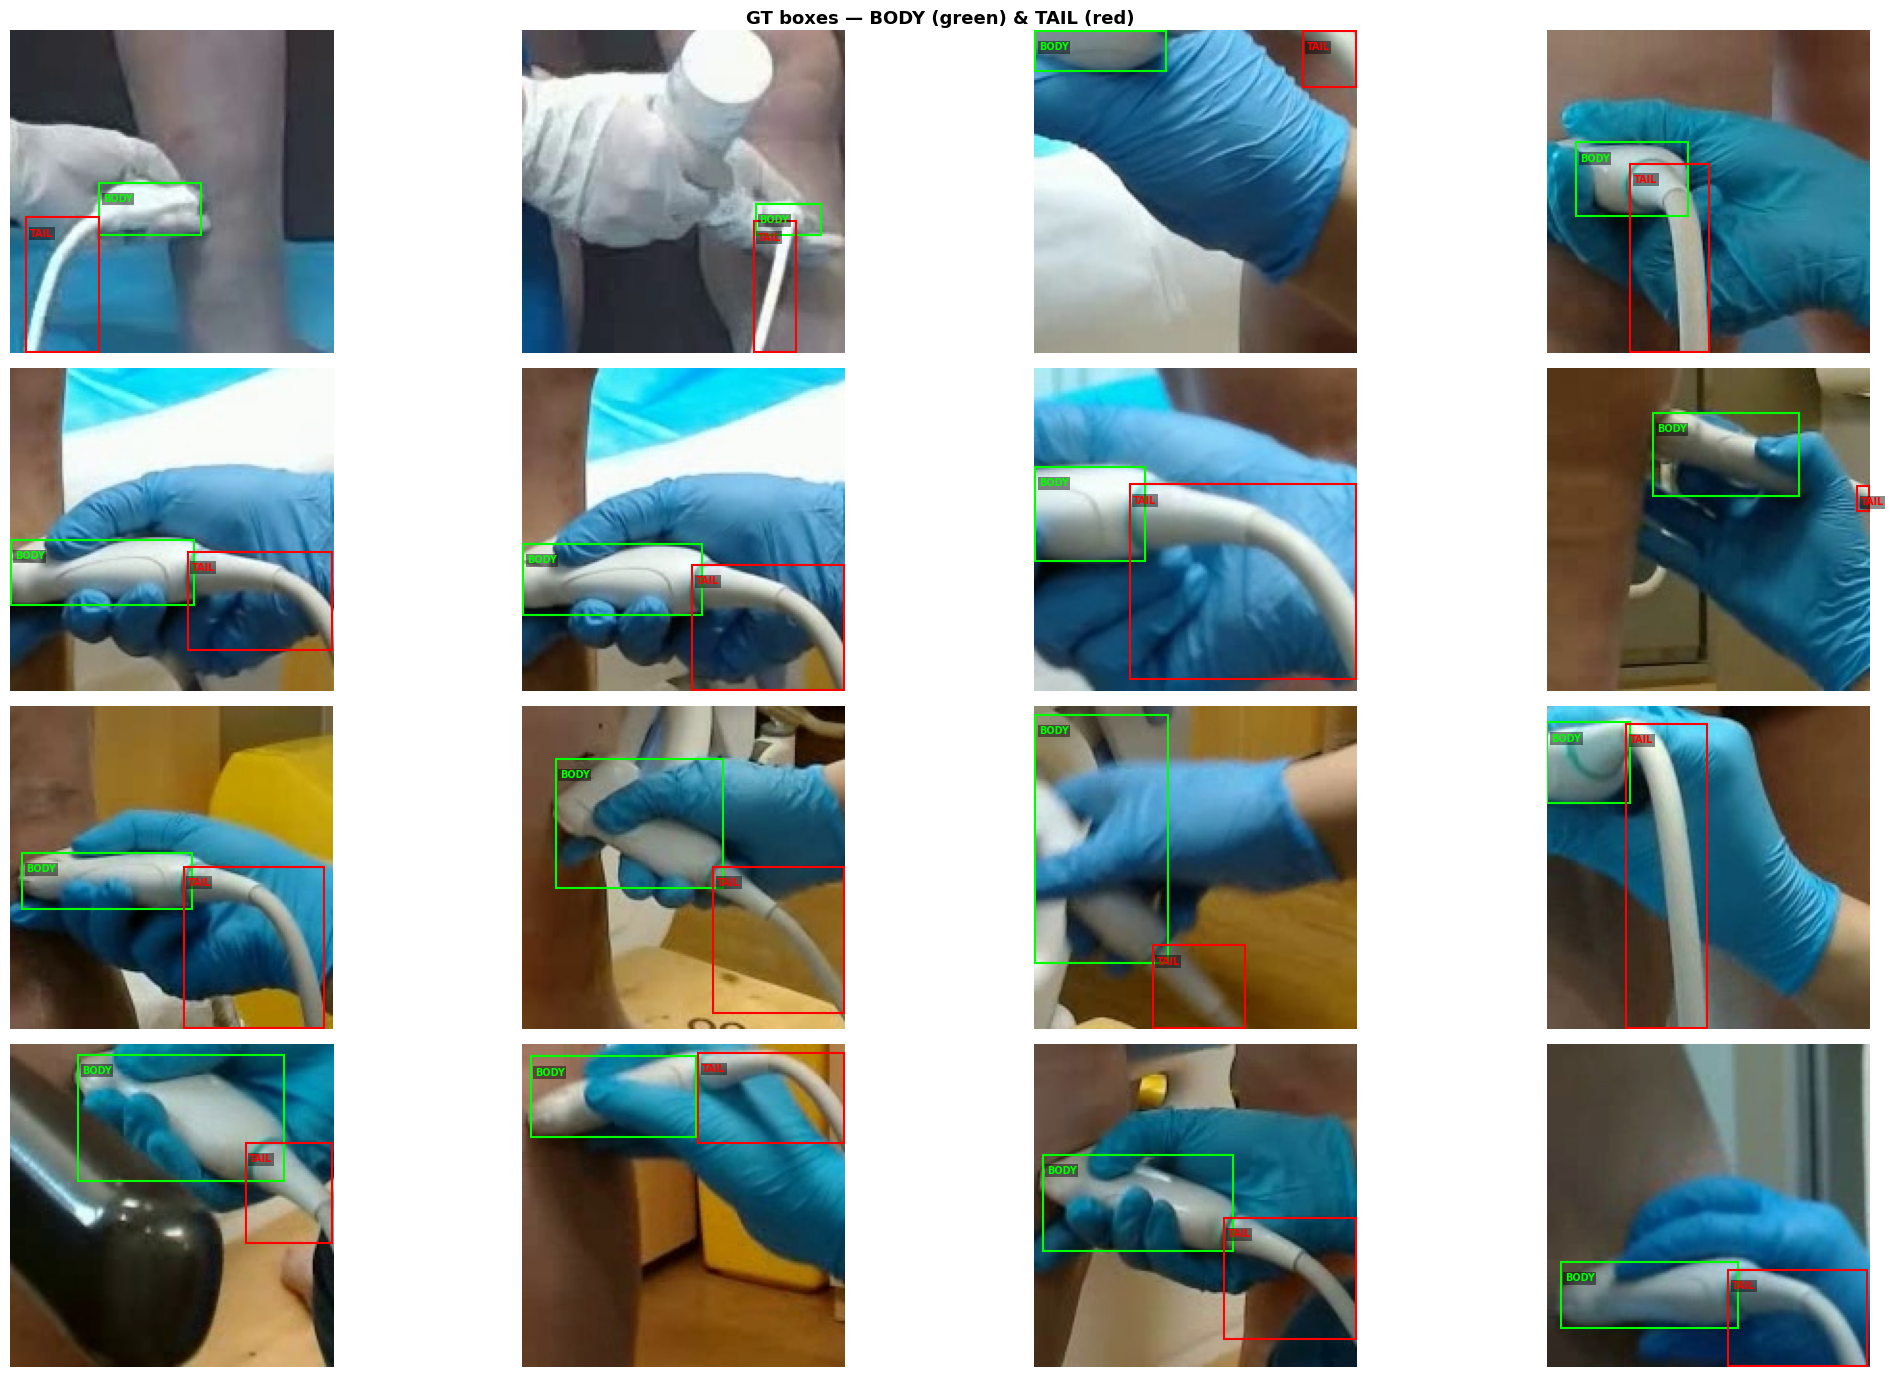

In [9]:
# ── 16-panel GT box grid (frames with both classes) ───────────────────────────
coco_train = load_coco('train')
id2img     = {i['id']: i for i in coco_train['images']}
img2anns   = defaultdict(list)
for a in coco_train['annotations']:
    img2anns[a['image_id']].append(a)

both_ids   = [iid for iid, anns in img2anns.items()
              if any(a['category_id']==1 for a in anns)
              and any(a['category_id']==2 for a in anns)]
sample_ids = random.sample(both_ids, min(16, len(both_ids)))

fig, axes = plt.subplots(4, 4, figsize=(22, 14))
fig.suptitle('GT boxes — BODY (green) & TAIL (red)', fontsize=13, fontweight='bold')
for ax, iid in zip(axes.flat, sample_ids):
    info    = id2img[iid]
    img_bgr = cv2.imread(os.path.join(DATASET_DIR, 'train', info['file_name']))
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    for ann in img2anns[iid]:
        x, y, w, h = ann['bbox']; cat = ann['category_id']
        ax.add_patch(mpatches.Rectangle((x,y), w, h,
                     linewidth=1.5, edgecolor=CLASS_COLORS[cat], facecolor='none'))
        ax.text(x+2, y+10, CLASS_NAMES[cat], color=CLASS_COLORS[cat],
                fontsize=7, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.45, pad=1, edgecolor='none'))
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(HERE, 'sample_grid.png'), dpi=120, bbox_inches='tight')
plt.show()

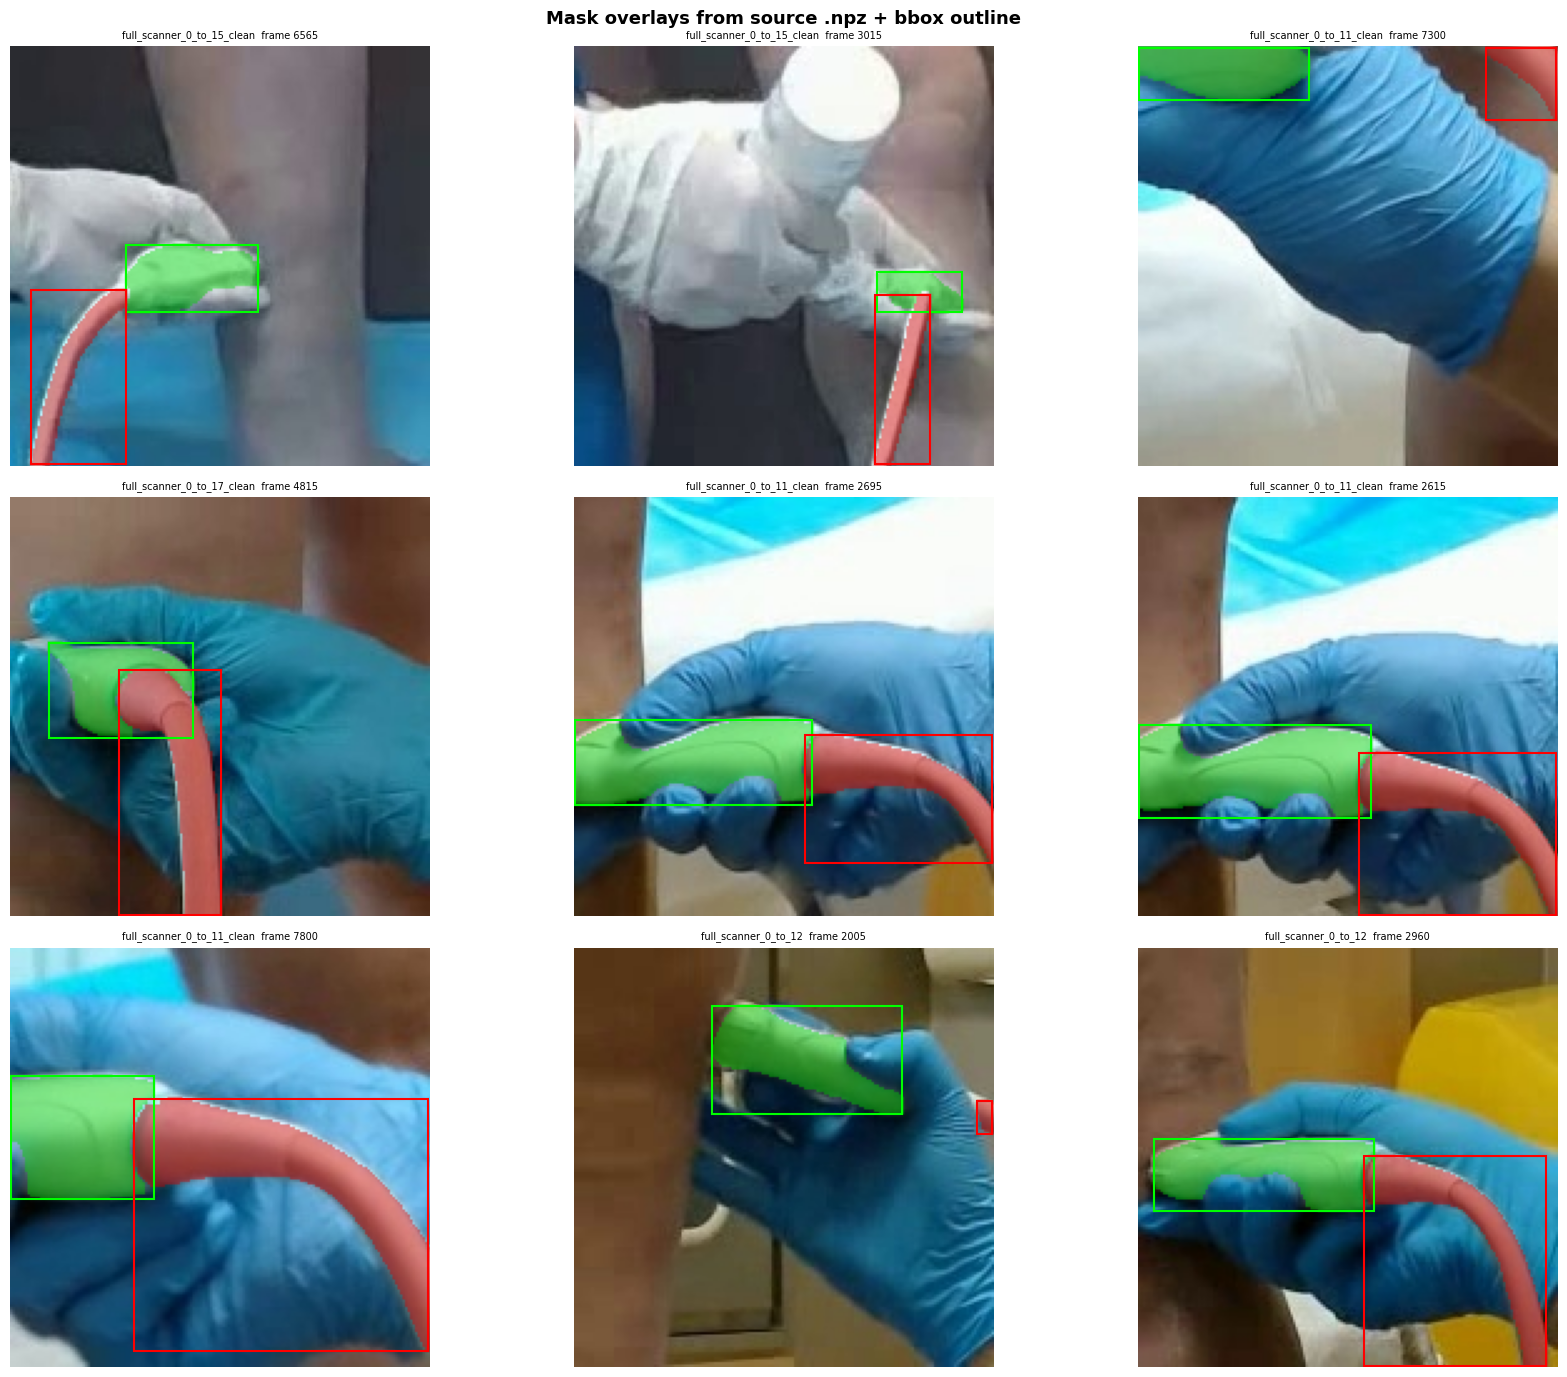

In [13]:
# ── 9-panel mask overlay grid ─────────────────────────────────────────────────
BODY_COLOR = np.array([0,   210,  0],  dtype=np.float32)
TAIL_COLOR = np.array([210,  0,   0],  dtype=np.float32)
ALPHA      = 0.45

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Mask overlays from source .npz + bbox outline', fontsize=13, fontweight='bold')

for ax, iid in zip(axes.flat, sample_ids[:9]):
    info  = id2img[iid]
    fname = info['file_name']                          # video__clip__fidx.jpg
    parts     = fname.replace('.jpg', '').split('__')
    # last part is always the frame index, second-to-last is the clip stem,
    # everything before is the video name (which may itself contain '__')
    fidx      = int(parts[-1])
    clip_stem = parts[-2]
    vid       = '__'.join(parts[:-2])

    img_bgr = cv2.imread(os.path.join(DATASET_DIR, 'train', fname))
    vis     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)

    seg_path  = os.path.join(ANNOTATED_VIDEOS_DIR, vid, 'segmentations_masks', clip_stem+'.npz')
    meta_path = os.path.join(ANNOTATED_VIDEOS_DIR, vid, 'cropped_clips_metadata', clip_stem+'.json')
    crop = None
    if os.path.exists(meta_path):
        with open(meta_path) as f: crop = json.load(f).get('crop_region')

    seg   = np.load(seg_path)
    masks = seg.get(str(fidx))
    seg.close()

    if masks is not None:
        for ch, raw in enumerate(masks):
            col = [BODY_COLOR, TAIL_COLOR][ch]
            if crop:
                x0, y0, x1, y1 = crop
                raw = raw[y0:y1, x0:x1]
            raw = clean_mask(raw.astype(np.uint8), KERNEL_SIZE, MORPH_ITERS)
            m3  = (raw > 0)[..., None].astype(np.float32)
            vis = vis*(1 - ALPHA*m3) + col*ALPHA*m3

    ax.imshow(np.clip(vis, 0, 255).astype(np.uint8))
    for ann in img2anns[iid]:
        x, y, w, h = ann['bbox']
        ax.add_patch(mpatches.Rectangle((x,y), w, h,
                     linewidth=1.5, edgecolor=CLASS_COLORS[ann['category_id']], facecolor='none'))
    ax.set_title(f'{clip_stem}  frame {fidx}', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(HERE, 'mask_overlay_grid.png'), dpi=120, bbox_inches='tight')
plt.show()

## 7. Estimate Training Time

Runs 5 warm-up iterations to measure actual GPU throughput before committing to full training.

In [11]:
import time

n_train = len(split_imgs['train'])
iters_per_epoch = max(1, n_train // BATCH_SIZE)
total_iters     = iters_per_epoch * EPOCHS

# Rough throughput benchmark: one forward+backward pass on dummy data
import torchvision.models as tvm
dummy_model = tvm.resnet50().to(DEVICE)
dummy_input = torch.randn(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
dummy_model.train()
opt = torch.optim.SGD(dummy_model.parameters(), lr=1e-3)

# Warm-up
for _ in range(2):
    opt.zero_grad(); dummy_model(dummy_input).sum().backward(); opt.step()
torch.cuda.synchronize()

t0 = time.perf_counter()
N_BENCH = 5
for _ in range(N_BENCH):
    opt.zero_grad(); dummy_model(dummy_input).sum().backward(); opt.step()
torch.cuda.synchronize()
sec_per_iter = (time.perf_counter() - t0) / N_BENCH
del dummy_model, dummy_input, opt
torch.cuda.empty_cache()

# RF-DETR is heavier than ResNet-50; apply a ~2× correction factor
estimated_sec = total_iters * sec_per_iter * 2
estimated_min = estimated_sec / 60

print(f'Training images  : {n_train:,}')
print(f'Batch size       : {BATCH_SIZE}')
print(f'Iters / epoch    : {iters_per_epoch:,}')
print(f'Total iters      : {total_iters:,}  ({EPOCHS} epochs)')
print(f'GPU throughput   : {1/sec_per_iter:.1f} it/s  (ResNet-50 proxy)')
print(f'Estimated time   : {estimated_min:.0f} min  (rough — RF-DETR overhead included)')

if estimated_min > 60:
    print(f'\n⚠  Estimate > 60 min — consider increasing FRAME_STRIDE '
          f'(currently {FRAME_STRIDE}) or reducing EPOCHS ({EPOCHS}).')
else:
    print(f'\n✅ Should finish within the hour.')

Training images  : 6,295
Batch size       : 16
Iters / epoch    : 393
Total iters      : 11,790  (30 epochs)
GPU throughput   : 11.6 it/s  (ResNet-50 proxy)
Estimated time   : 34 min  (rough — RF-DETR overhead included)

✅ Should finish within the hour.


## 8. Train RF-DETR

In [17]:
# %pip install "rfdetr[train,loggers]" --quiet

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location

In [20]:
model = MODEL_CLASS(
    num_classes=len(CATEGORIES),
    resolution=IMG_SIZE,
    device=DEVICE,
)

model.train(
    dataset_dir=DATASET_DIR,
    epochs=25,
    batch_size=32,          # doubled — 5090 can handle it
    lr=LR,
    output_dir=RUNS_DIR,
    dataset_file='roboflow',
    grad_accum_steps=1,     # no accumulation — biggest speedup
    multi_scale=False,      # fixed resolution — faster dataloading
)


[2026-09-04 17:49:28] [INFO] rf-detr - File C:\Users\Krish\.roboflow\models\rf-detr-small.pth already exists with correct MD5 hash.


[2026-09-04 17:49:28] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-04 17:49:28] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-04 17:49:29] [INFO] rf-detr - File C:\Users\Krish\.roboflow\models\rf-detr-small.pth already exists with correct MD5 hash.


[2026-09-04 17:49:30] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 2. The detection head will be re-initialized to 2 classes.
[2026-09-04 17:49:30] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-04 17:49:30] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-04 17:49:30] [INFO] rf-detr - File C:\Users\Krish\.roboflow\models\rf-detr-small.pth already exists with correct MD5 hash.


...

[2026-09-04 17:56:14] [INFO] rf-detr - Best EMA mAP improved to 0.0758 (epoch 2)


[2026-09-04 17:59:21] [INFO] rf-detr - Best regular checkpoint saved to C:\Users\Krish\Desktop\scanner-annotation\REDetr_Probe_Detection_Training\runs\checkpoint_best_regular.pth (epoch 3, monitor=val/mAP_50_95, value=0.0816345)
[2026-09-04 17:59:21] [INFO] rf-detr - Best EMA mAP improved to 0.0796 (epoch 3)


[2026-09-04 18:01:26] [INFO] rf-detr - Best EMA mAP improved to 0.0850 (epoch 4)



Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

In [21]:
from rfdetr import RFDETRNano

model = RFDETRNano(
    num_classes=len(CATEGORIES),
    resolution=448,
    device=DEVICE,
)

model.train(
    dataset_dir=DATASET_DIR,
    epochs=10,
    batch_size=32,
    lr=1e-4,
    output_dir=RUNS_DIR,
    dataset_file='roboflow',
    grad_accum_steps=1,
    multi_scale=False,
)

[2026-09-04 18:01:46] [INFO] rf-detr - Downloading pretrained weights for C:\Users\Krish\.roboflow\models\rf-detr-nano.pth


C:\Users\Krish\.roboflow\models\rf-detr-nano.pth:   0%|          | 0.00/349M [00:00<?, ?iB/s]

[2026-09-04 18:02:20] [INFO] rf-detr - MD5 validation successful for C:\Users\Krish\.roboflow\models\rf-detr-nano.pth


[2026-09-04 18:02:20] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-04 18:02:20] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-04 18:02:21] [INFO] rf-detr - File C:\Users\Krish\.roboflow\models\rf-detr-nano.pth already exists with correct MD5 hash.


...

[2026-09-04 18:07:35] [INFO] rf-detr - Best regular checkpoint saved to C:\Users\Krish\Desktop\scanner-annotation\REDetr_Probe_Detection_Training\runs\checkpoint_best_regular.pth (epoch 2, monitor=val/mAP_50_95, value=0.20154)
[2026-09-04 18:07:35] [INFO] rf-detr - Best EMA mAP improved to 0.2011 (epoch 2)


[2026-09-04 18:11:16] [INFO] rf-detr - Best EMA mAP improved to 0.2045 (epoch 4)


[2026-09-04 18:14:53] [INFO] rf-detr - Best regular checkpoint saved to C:\Users\Krish\Desktop\scanner-annotation\REDetr_Probe_Detection_Training\runs\checkpoint_best_regular.pth (epoch 6, monitor=val/mAP_50_95, value=0.202376)
[2026-09-04 18:14:53] [INFO] rf-detr - Best EMA mAP improved to 0.2075 (epoch 6)


`Trainer.fit` stopped: `max_epochs=10` reached.


[2026-09-04 18:20:32] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.2024, ema=0.2075)


In [24]:
from rfdetr import RFDETRSmall

model = RFDETRSmall(
    num_classes=len(CATEGORIES),
    resolution=560,
    device=DEVICE,
)

model.train(
    dataset_dir=DATASET_DIR,
    epochs=20,
    batch_size=16,
    lr=1e-4,
    output_dir=RUNS_DIR,
    dataset_file='roboflow',
    checkpoint_interval=5,
)

[2026-09-04 18:24:27] [INFO] rf-detr - File C:\Users\Krish\.roboflow\models\rf-detr-small.pth already exists with correct MD5 hash.


[2026-09-04 18:24:27] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-04 18:24:27] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-04 18:24:28] [INFO] rf-detr - File C:\Users\Krish\.roboflow\models\rf-detr-small.pth already exists with correct MD5 hash.


[2026-09-04 18:24:29] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 2. The detection head will be re-initialized to 2 classes.
[2026-09-04 18:24:29] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-04 18:24:29] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-04 18:24:30] [INFO] rf-detr - File C:\Users\Krish\.roboflow\models\rf-detr-small.pth already exists with correct MD5 hash.


...

Output()

[2026-09-04 18:27:19] [INFO] rf-detr - Best regular checkpoint saved to C:\Users\Krish\Desktop\scanner-annotation\REDetr_Probe_Detection_Training\runs\checkpoint_best_regular.pth (epoch 0, monitor=val/mAP_50_95, value=0.215613)
[2026-09-04 18:27:20] [INFO] rf-detr - Best EMA mAP improved to 0.2164 (epoch 0)


[2026-09-04 18:34:35] [INFO] rf-detr - Best regular checkpoint saved to C:\Users\Krish\Desktop\scanner-annotation\REDetr_Probe_Detection_Training\runs\checkpoint_best_regular.pth (epoch 3, monitor=val/mAP_50_95, value=0.221985)



Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

In [25]:
from rfdetr import RFDETRSmall

model = RFDETRSmall(
    num_classes=len(CATEGORIES),
    resolution=560,
    device=DEVICE,
)

model.train(
    dataset_dir=DATASET_DIR,
    epochs=5,
    batch_size=64,
    lr=10e-4,          # 5x higher — forces faster convergence
    output_dir=RUNS_DIR,
    dataset_file='roboflow',
    grad_accum_steps=1,
    multi_scale=False,
)


[2026-09-04 18:40:02] [INFO] rf-detr - File C:\Users\Krish\.roboflow\models\rf-detr-small.pth already exists with correct MD5 hash.


[2026-09-04 18:40:02] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-04 18:40:02] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-04 18:40:04] [INFO] rf-detr - File C:\Users\Krish\.roboflow\models\rf-detr-small.pth already exists with correct MD5 hash.


[2026-09-04 18:40:05] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 2. The detection head will be re-initialized to 2 classes.
[2026-09-04 18:40:05] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-04 18:40:05] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-04 18:40:06] [INFO] rf-detr - File C:\Users\Krish\.roboflow\models\rf-detr-small.pth already exists with correct MD5 hash.


...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model       │ LWDETR       │ 31.9 M │ train │     0 │
│ 1 │ criterion   │ SetCriterion │      0 │ train │     0 │
│ 2 │ postprocess │ PostProcess  │      0 │ train │     0 │
└───┴─────────────┴──────────────┴────────┴───────┴───────┘

Trainable params: 31.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 31.9 M                                                                                               
Total estimated model params size (MB): 127.487                                                                    
Modules in train mode: 466                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

OutOfMemoryError: CUDA out of memory. Tried to allocate 732.00 MiB. GPU 0 has a total capacity of 31.84 GiB of which 0 bytes is free. Of the allocated memory 36.50 GiB is allocated by PyTorch, and 4.09 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

## 9. Evaluate & Visualise Predictions

In [22]:
from rfdetr import from_checkpoint

# Find best checkpoint
ckpt_path = os.path.join(RUNS_DIR, 'checkpoint_best_total.pth')
if not os.path.exists(ckpt_path):
    candidates = sorted(f for f in os.listdir(RUNS_DIR) if f.endswith('.pth'))
    ckpt_path  = os.path.join(RUNS_DIR, candidates[-1]) if candidates else None
    print(f'Best checkpoint not found — using: {candidates[-1] if candidates else "NONE"}')

print(f'Loading: {ckpt_path}')
eval_model = from_checkpoint(ckpt_path)


c:\Users\Krish\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rfdetr\detr.py:551: FutureWarning: The `RFDETRBase` was deprecated since v1.7.0. It will be removed in v2.0.0.
  getattr(variant_obj, "__name__", symbol): variant_obj
c:\Users\Krish\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rfdetr\detr.py:551: FutureWarning: The `RFDETRLargeDeprecated` was deprecated since v1.7.0. It will be removed in v2.0.0.
  getattr(variant_obj, "__name__", symbol): variant_obj
c:\Users\Krish\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rfdetr\detr.py:551: FutureWarning: The `RFDETRSegPreview` was deprecated since v1.7.0. It will be removed in v2.0.0.
  getattr(variant_obj, "__name__", symbol): variant_obj
[2026-09-04 18:23:47] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-04 18:23:47] [WARNING] rf-detr 

Loading: c:\Users\Krish\Desktop\scanner-annotation\REDetr_Probe_Detection_Training\runs\checkpoint_best_total.pth


In [26]:
# ── COCO mAP on test split ────────────────────────────────────────────────────
from rfdetr import from_checkpoint

ckpt_path = os.path.join(RUNS_DIR, 'checkpoint_best_total.pth')
eval_model = from_checkpoint(ckpt_path)

eval_model.evaluate(
    dataset_dir=DATASET_DIR,
    dataset_file='roboflow',
    device=DEVICE,
)

[2026-09-04 18:46:37] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-04 18:46:37] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-04 18:46:37] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-04 18:46:37] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-04 18:46:37] [INFO] rf-detr - Building Roboflow test dataset with square resize at resolution 384
[2026-09-04 18:46:37] [INFO] rf-detr - Using multi-scale training with square resize and scales: [544]


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


c:\Users\Krish\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/AP/BODY        │    0.11042545735836029    │
│       test/AP/TAIL        │    0.46870675683021545    │
│          test/F1          │     0.516506016254425     │
│         test/loss         │     5.995603084564209     │
│        test/mAP_50        │    0.4514765739440918     │
│      test/mAP_50_95       │    0.2895660996437073     │
│        test/mAP_75        │     0.295490562915802     │
│         test/mAR          │    0.7416982650756836     │
│      test/precision       │    0.4740014672279358     │
│        test/recall        │    0.6538816094398499     │
└───────────────────────────┴───────────────────────────┘

{'test/loss': 5.995603084564209,
 'test/mAP_50_95': 0.2895660996437073,
 'test/mAP_50': 0.4514765739440918,
 'test/mAP_75': 0.295490562915802,
 'test/mAR': 0.7416982650756836,
 'test/F1': 0.516506016254425,
 'test/precision': 0.4740014672279358,
 'test/recall': 0.6538816094398499,
 'test/AP/BODY': 0.11042545735836029,
 'test/AP/TAIL': 0.46870675683021545}

[2026-09-04 18:48:15] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).


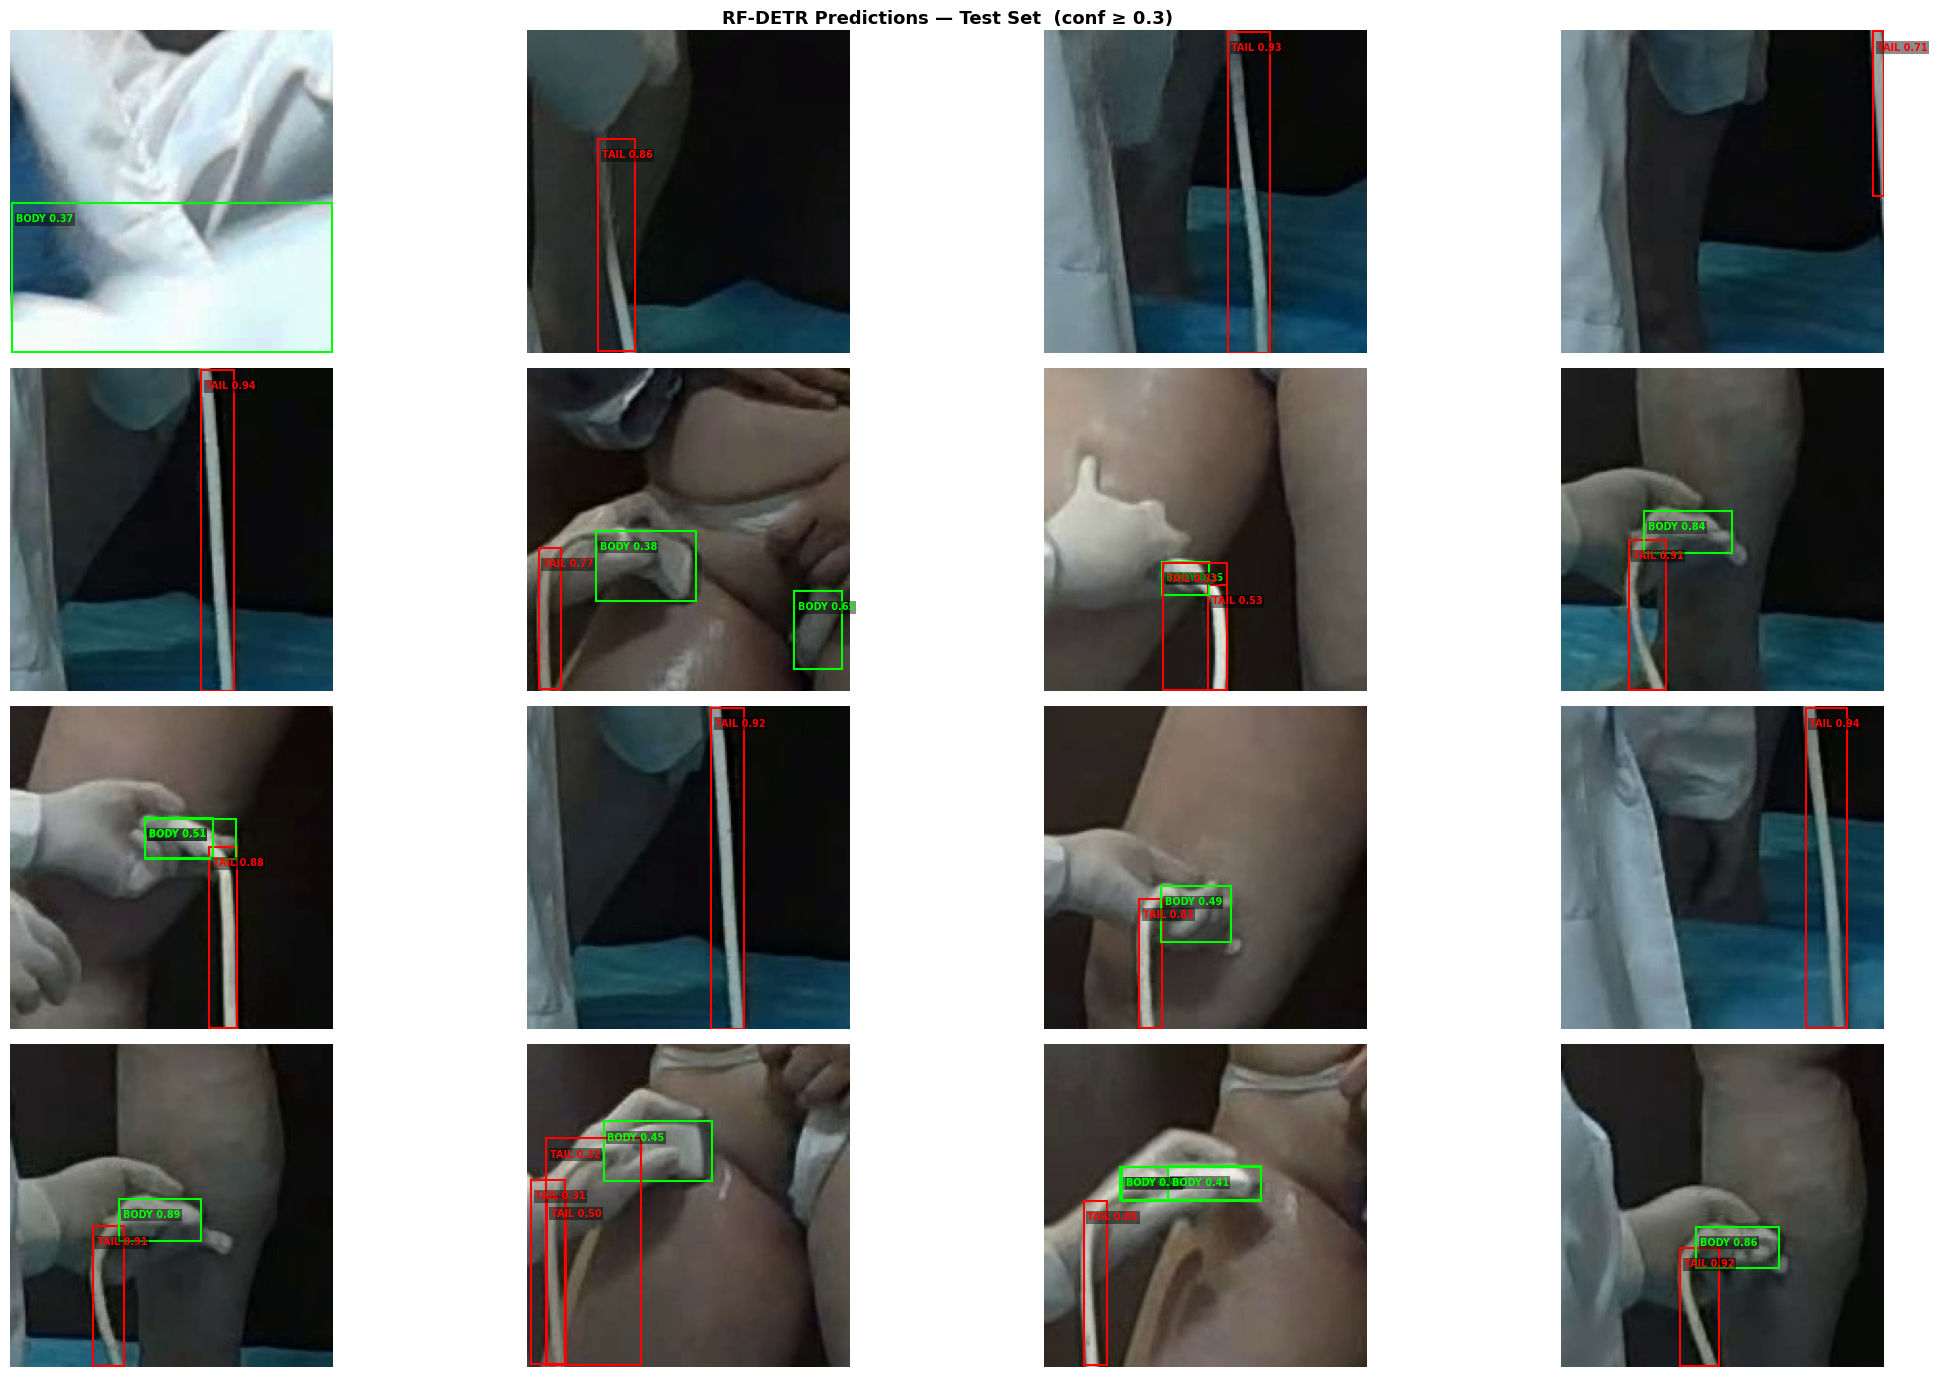

In [27]:
# ── 16-panel qualitative predictions on test images ───────────────────────────
CONF_THRESH = 0.3

coco_test   = load_coco('test')
sample_test = random.sample(coco_test['images'], min(16, len(coco_test['images'])))

fig, axes = plt.subplots(4, 4, figsize=(22, 14))
fig.suptitle(f'RF-DETR Predictions — Test Set  (conf ≥ {CONF_THRESH})', fontsize=13, fontweight='bold')

for ax, info in zip(axes.flat, sample_test):
    img_path = os.path.join(DATASET_DIR, 'test', info['file_name'])
    img_bgr  = cv2.imread(img_path)
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

    dets = eval_model.predict(img_path, threshold=CONF_THRESH)
    if dets is not None and len(dets.xyxy) > 0:
        for box, cls_id, conf in zip(dets.xyxy, dets.class_id, dets.confidence):
            x0, y0, x1, y1 = box
            cat   = int(cls_id) + 1
            color = CLASS_COLORS.get(cat, 'white')
            ax.add_patch(mpatches.Rectangle(
                (x0, y0), x1-x0, y1-y0,
                linewidth=1.5, edgecolor=color, facecolor='none'))
            ax.text(x0+2, y0+10, f"{CLASS_NAMES.get(cat,str(cat))} {conf:.2f}",
                    color=color, fontsize=7, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.45, pad=1, edgecolor='none'))
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(HERE, 'predictions_test.png'), dpi=120, bbox_inches='tight')
plt.show()